In [1]:
# HealthGuard AI - Heart Disease Model Training
# Author: HealthGuard AI Team
# Date: 2026
# Version: 2.0 - Complete with Hyperparameter Tuning,
#                Cross Validation, ROC Curve, SHAP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report,
                             roc_curve, auc)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     StratifiedKFold)
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8')

print("=" * 50)
print("  HealthGuard AI - Heart Disease Model Training v2.0")
print("=" * 50)
print("Libraries Loaded Successfully!")

  HealthGuard AI - Heart Disease Model Training v2.0
Libraries Loaded Successfully!


In [2]:
# Load Cleaned Train and Test Data

X_train = pd.read_csv("E:/HealthGuard_AI/data/processed/heart_X_train.csv")
X_test = pd.read_csv("E:/HealthGuard_AI/data/processed/heart_X_test.csv")
y_train = pd.read_csv("E:/HealthGuard_AI/data/processed/heart_y_train.csv").values.ravel()
y_test = pd.read_csv("E:/HealthGuard_AI/data/processed/heart_y_test.csv").values.ravel()

print("Data Loaded Successfully!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"\nTraining Class Distribution:")
print(f"No Disease: {(y_train==0).sum()}")
print(f"Disease: {(y_train==1).sum()}")

Data Loaded Successfully!
X_train Shape: (252, 13)
X_test Shape: (57, 13)

Training Class Distribution:
No Disease: 126
Disease: 126


STEP 1: CROSS VALIDATION (5-FOLD)
Cross Validation Results:
----------------------------------------

Logistic Regression:
  Mean F1: 0.8170
  Std F1:  0.0481
  Scores:  [0.8772 0.8077 0.7925 0.7451 0.8627]

Random Forest:
  Mean F1: 0.8461
  Std F1:  0.0586
  Scores:  [0.9615 0.8163 0.8364 0.8077 0.8085]

XGBoost:
  Mean F1: 0.8355
  Std F1:  0.0593
  Scores:  [0.9259 0.88   0.7636 0.8163 0.7917]

SVM:
  Mean F1: 0.8379
  Std F1:  0.0659
  Scores:  [0.9434 0.8235 0.8727 0.75   0.8   ]

Neural Network:
  Mean F1: 0.8430
  Std F1:  0.0380
  Scores:  [0.902  0.8163 0.8421 0.7917 0.8627]


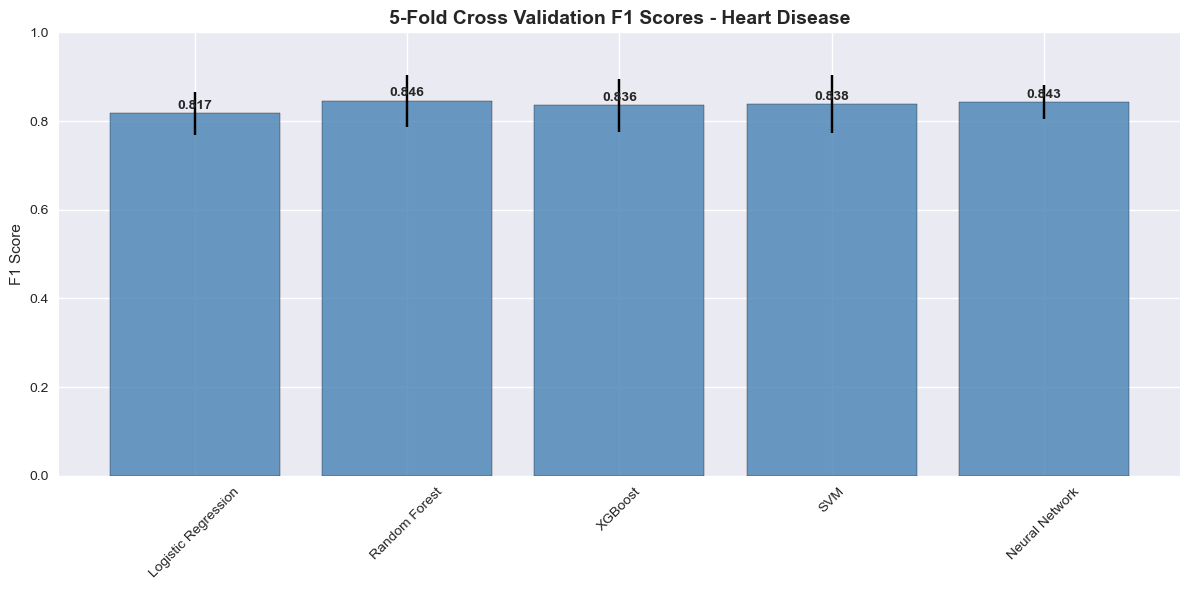


Cross Validation Complete!


In [3]:
# Step 1: Cross Validation

print("=" * 50)
print("STEP 1: CROSS VALIDATION (5-FOLD)")
print("=" * 50)

cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

base_models = {
    'Logistic Regression': LogisticRegression(random_state=42,
                                              max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100,
                                           random_state=42),
    'XGBoost': XGBClassifier(random_state=42,
                              eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50),
                                    max_iter=500,
                                    random_state=42)
}

cv_results = {}

print("Cross Validation Results:")
print("-" * 40)

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1')
    cv_results[name] = {
        'Mean F1': cv_scores.mean(),
        'Std F1': cv_scores.std(),
        'All Scores': cv_scores
    }
    print(f"\n{name}:")
    print(f"  Mean F1: {cv_scores.mean():.4f}")
    print(f"  Std F1:  {cv_scores.std():.4f}")
    print(f"  Scores:  {cv_scores.round(4)}")

plt.figure(figsize=(12, 6))
names = list(cv_results.keys())
means = [cv_results[n]['Mean F1'] for n in names]
stds = [cv_results[n]['Std F1'] for n in names]

bars = plt.bar(names, means, yerr=stds,
               color='steelblue', edgecolor='black',
               capsize=5, alpha=0.8)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', fontweight='bold')

plt.title('5-Fold Cross Validation F1 Scores - Heart Disease',
          fontweight='bold', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nCross Validation Complete!")

In [4]:
# Step 2: Hyperparameter Tuning

print("=" * 50)
print("STEP 2: HYPERPARAMETER TUNING")
print("=" * 50)

print("Tuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF F1: {rf_grid.best_score_:.4f}")

print("\nTuning XGBoost...")
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"Best XGB F1: {xgb_grid.best_score_:.4f}")

print("\nHyperparameter Tuning Complete!")

STEP 2: HYPERPARAMETER TUNING
Tuning Random Forest...
Best RF Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF F1: 0.8737

Tuning XGBoost...
Best XGB Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best XGB F1: 0.8649

Hyperparameter Tuning Complete!


In [5]:
# Step 3: Train Final Models

print("=" * 50)
print("STEP 3: TRAIN FINAL MODELS")
print("=" * 50)

final_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000),
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'SVM': SVC(probability=True, random_state=42, C=1.0),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500, random_state=42)
}

results = {}

for name, model in final_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC ROC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Model': model
    }

    print(f"Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"F1 Score:  {results[name]['F1 Score']:.4f}")
    print(f"AUC ROC:   {results[name]['AUC ROC']:.4f}")

print("\nAll Models Trained!")

STEP 3: TRAIN FINAL MODELS

Training Logistic Regression...
Accuracy:  0.7544
F1 Score:  0.7742
AUC ROC:   0.8613

Training Random Forest...
Accuracy:  0.8070
F1 Score:  0.8254
AUC ROC:   0.8662

Training XGBoost...
Accuracy:  0.7719
F1 Score:  0.8000
AUC ROC:   0.8450

Training SVM...
Accuracy:  0.8070
F1 Score:  0.8308
AUC ROC:   0.8475

Training Neural Network...
Accuracy:  0.7895
F1 Score:  0.8182
AUC ROC:   0.8313

All Models Trained!


STEP 4: MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.7544     0.8000  0.7500    0.7742   0.8612
Random Forest          0.8070     0.8387  0.8125    0.8254   0.8662
XGBoost                0.7719     0.7879  0.8125    0.8000   0.8450
SVM                    0.8070     0.8182  0.8438    0.8308   0.8475
Neural Network         0.7895     0.7941  0.8438    0.8182   0.8312


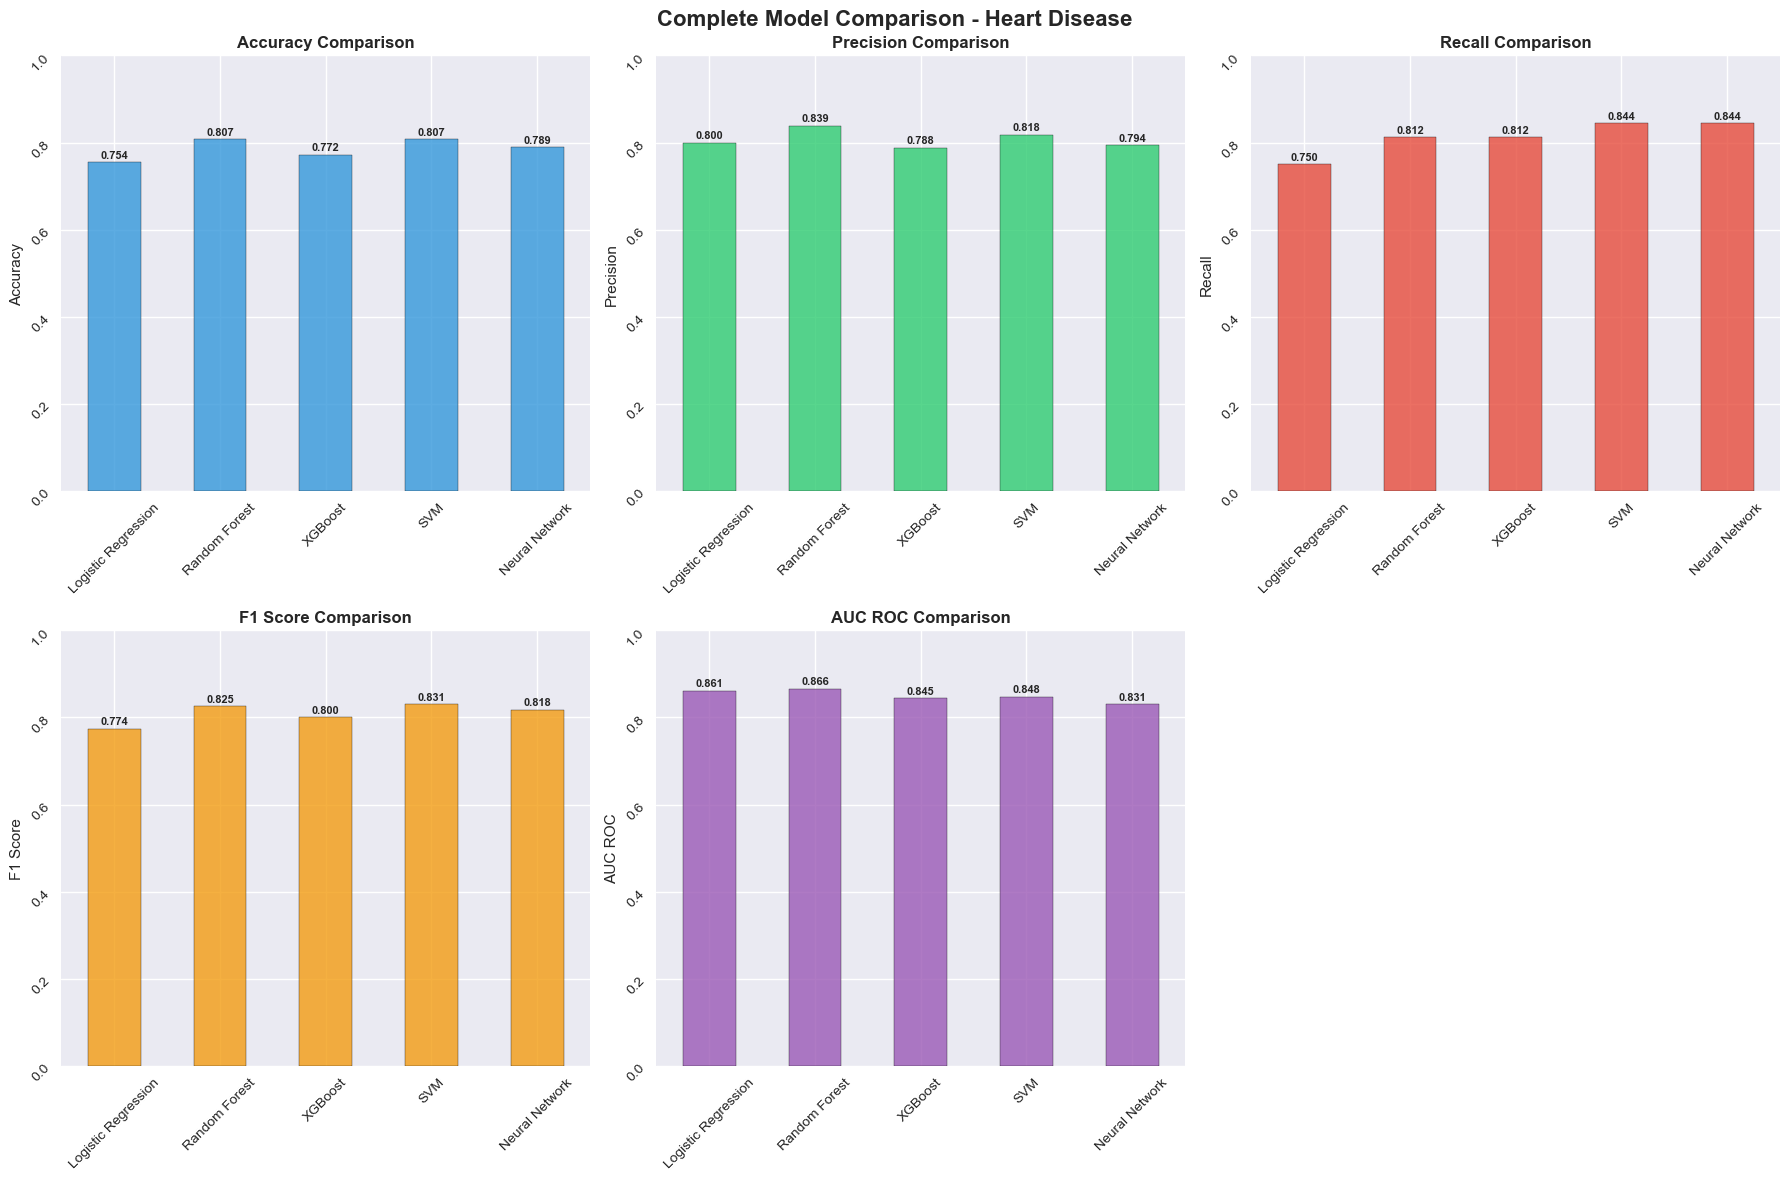

In [6]:
# Step 4: Model Comparison

print("=" * 50)
print("STEP 4: MODEL COMPARISON")
print("=" * 50)

results_df = pd.DataFrame({
    name: {
        'Accuracy': results[name]['Accuracy'],
        'Precision': results[name]['Precision'],
        'Recall': results[name]['Recall'],
        'F1 Score': results[name]['F1 Score'],
        'AUC ROC': results[name]['AUC ROC']
    }
    for name in results
}).T.round(4)

print(results_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall',
           'F1 Score', 'AUC ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c',
          '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar',
                            ax=axes[i],
                            color=colors[i],
                            edgecolor='black',
                            alpha=0.8)
    axes[i].set_title(f'{metric} Comparison',
                      fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(rotation=45)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=8,
                    fontweight='bold')

axes[5].set_visible(False)

plt.suptitle('Complete Model Comparison - Heart Disease',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 5: ROC CURVE


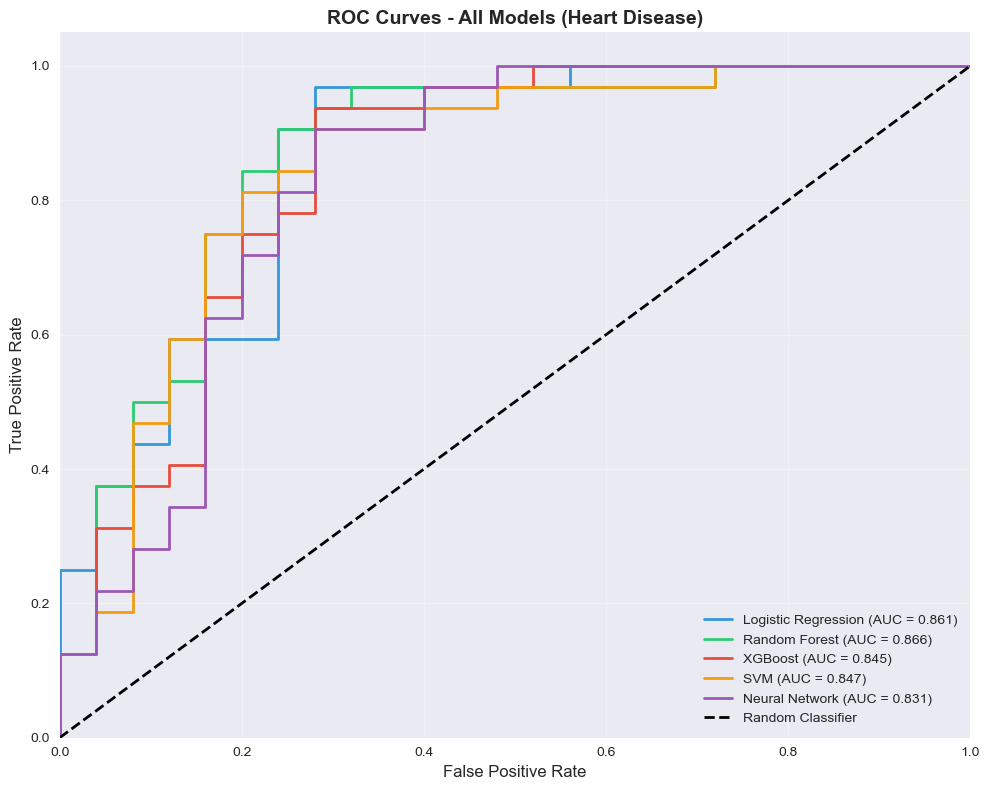

ROC Curve Complete!


In [7]:
# Step 5: ROC Curve

print("=" * 50)
print("STEP 5: ROC CURVE")
print("=" * 50)

plt.figure(figsize=(10, 8))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c',
              '#f39c12', '#9b59b6']

for (name, result), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2,
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Heart Disease)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC Curve Complete!")

STEP 6: BEST MODEL & CONFUSION MATRIX
Best Model: SVM
Accuracy:  0.8070
Precision: 0.8182
Recall:    0.8438
F1 Score:  0.8308
AUC ROC:   0.8475


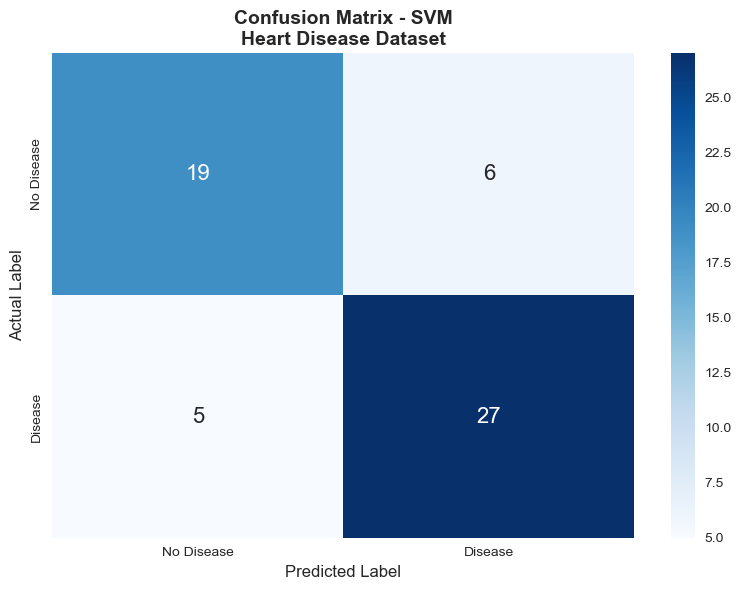


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.76      0.78        25
     Disease       0.82      0.84      0.83        32

    accuracy                           0.81        57
   macro avg       0.80      0.80      0.80        57
weighted avg       0.81      0.81      0.81        57



In [8]:
# Step 6: Best Model & Confusion Matrix

print("=" * 50)
print("STEP 6: BEST MODEL & CONFUSION MATRIX")
print("=" * 50)

best_model_name = results_df['F1 Score'].idxmax()
best_model = results[best_model_name]['Model']
y_pred_best = results[best_model_name]['y_pred']

print(f"Best Model: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - {best_model_name}\n'
          f'Heart Disease Dataset',
          fontweight='bold', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=['No Disease', 'Disease']))

STEP 7: SHAP EXPLAINABILITY


  0%|          | 0/57 [00:00<?, ?it/s]

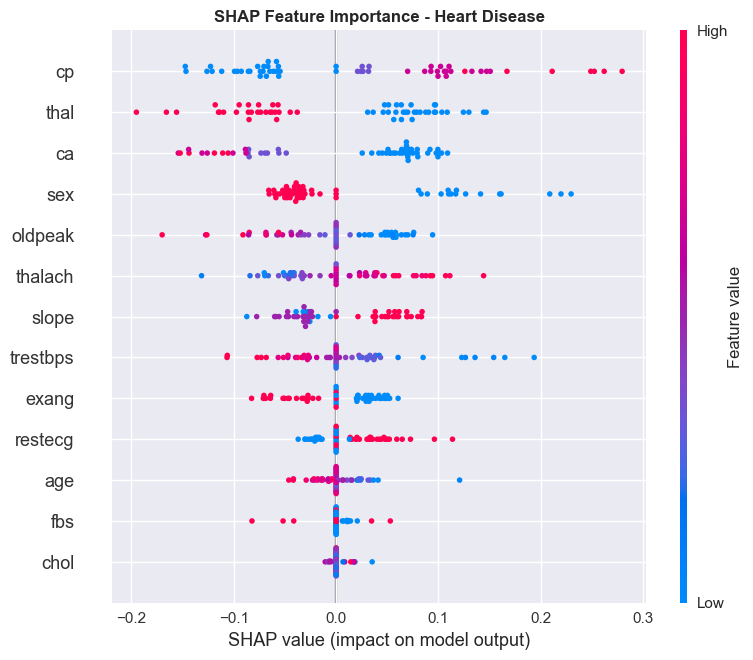

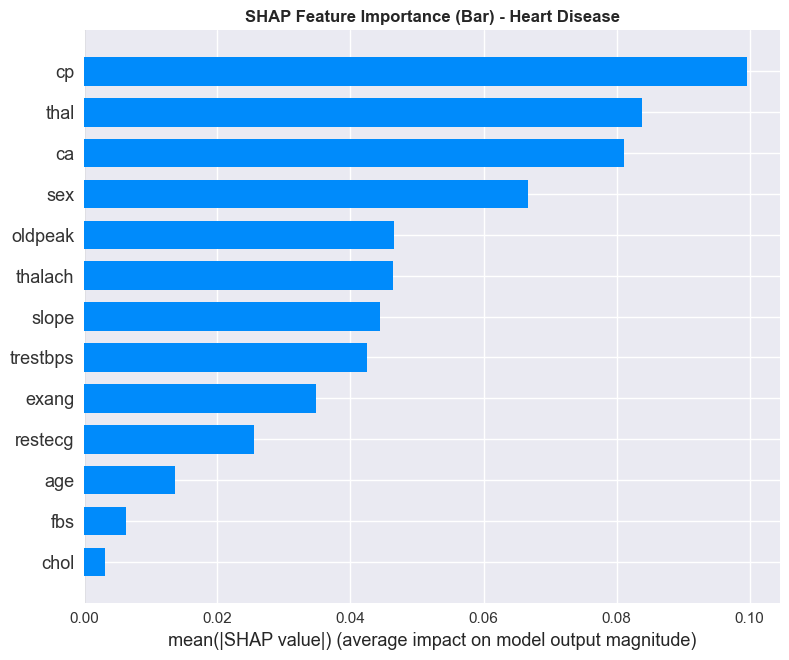

SHAP Analysis Complete!

Top Features by SHAP:
cp          0.099578
thal        0.083771
ca          0.081086
sex         0.066638
oldpeak     0.046594
thalach     0.046341
slope       0.044497
trestbps    0.042547
exang       0.034853
restecg     0.025529
age         0.013667
fbs         0.006254
chol        0.003116
dtype: float64


In [9]:
# Step 7: SHAP Explainability

print("=" * 50)
print("STEP 7: SHAP EXPLAINABILITY")
print("=" * 50)

if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.KernelExplainer(
        best_model.predict_proba,
        shap.sample(X_train, 100))

shap_values = explainer.shap_values(X_test)

# Fix for 2D SHAP values
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

if len(shap_vals.shape) > 2:
    shap_vals = shap_vals[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance - Heart Disease',
          fontweight='bold')
plt.tight_layout()
plt.savefig('E:/HealthGuard_AI/reports/heart_shap.png',
            dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Bar) - Heart Disease',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("SHAP Analysis Complete!")

shap_importance = pd.Series(
    np.abs(shap_vals).mean(axis=0).flatten(),
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop Features by SHAP:")
print(shap_importance)

In [10]:
# Step 8: Save Best Model

print("=" * 50)
print("STEP 8: SAVE MODEL")
print("=" * 50)

model_path = "E:/HealthGuard_AI/models/saved/heart_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test[:5])
print(f"Model: {best_model_name}")
print(f"Saved at: {model_path}")
print(f"Verification: {test_pred}")
print("Model Saved and Verified!")

STEP 8: SAVE MODEL
Model: SVM
Saved at: E:/HealthGuard_AI/models/saved/heart_model.pkl
Verification: [0 1 1 1 0]
Model Saved and Verified!


In [11]:
# Final Summary

print("=" * 60)
print("   HEART DISEASE MODEL TRAINING - FINAL SUMMARY")
print("=" * 60)

print("\nCROSS VALIDATION RESULTS:")
print("-" * 40)
for name, cv in cv_results.items():
    print(f"{name}: {cv['Mean F1']:.4f} (+/- {cv['Std F1']:.4f})")

print("\nFINAL MODEL PERFORMANCE:")
print("-" * 40)
print(results_df.to_string())

print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

print(f"\nModel saved: heart_model.pkl")
print("\nHeart Disease Model Training Complete! ")
print("=" * 60)

   HEART DISEASE MODEL TRAINING - FINAL SUMMARY

CROSS VALIDATION RESULTS:
----------------------------------------
Logistic Regression: 0.8170 (+/- 0.0481)
Random Forest: 0.8461 (+/- 0.0586)
XGBoost: 0.8355 (+/- 0.0593)
SVM: 0.8379 (+/- 0.0659)
Neural Network: 0.8430 (+/- 0.0380)

FINAL MODEL PERFORMANCE:
----------------------------------------
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    0.7544     0.8000  0.7500    0.7742   0.8612
Random Forest          0.8070     0.8387  0.8125    0.8254   0.8662
XGBoost                0.7719     0.7879  0.8125    0.8000   0.8450
SVM                    0.8070     0.8182  0.8438    0.8308   0.8475
Neural Network         0.7895     0.7941  0.8438    0.8182   0.8312

BEST MODEL: SVM
Accuracy:  0.8070
Precision: 0.8182
Recall:    0.8438
F1 Score:  0.8308
AUC ROC:   0.8475

Model saved: heart_model.pkl

Heart Disease Model Training Complete! 
